In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

In [13]:
intake_path = r'\\idc-efiler01\Groups04\ASTRUSINS\Actuarial\Alliant\Arevon\2025\Arevon - Loss Projections 2025.xlsx'
input_loss = pd.read_excel(intake_path , sheet_name = "Simulation Input" , skiprows = 2, usecols = "A")
input_exposure = pd.read_excel(intake_path, sheet_name="Simulation Input", skiprows = 2, usecols=[2, 3, 4])

ParserError: Defining usecols with out-of-bounds indices is not allowed. [2, 3, 4] are out-of-bounds. (sheet: Simulation Input)

In [9]:
input_exposure

NameError: name 'input_exposure' is not defined

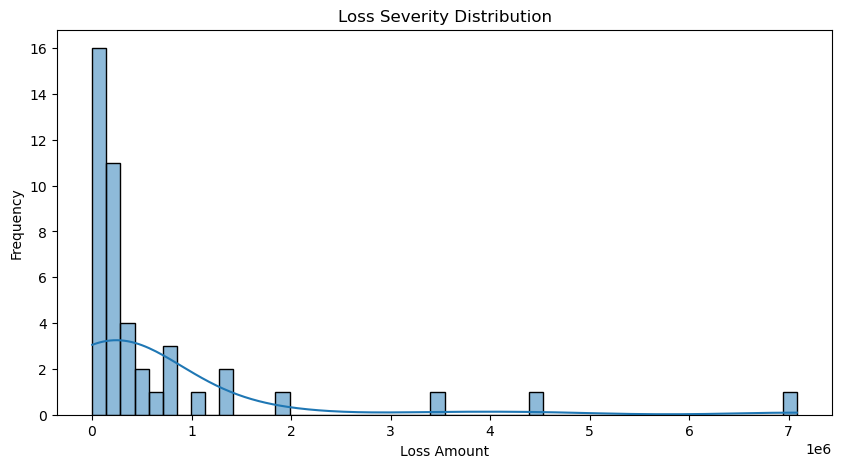

In [16]:
# Step 1: Inspect the data
losses = input_loss['Loss'].dropna()
losses = losses[losses > 0]  # Only positive losses

# Step 2: Visualize loss distribution
plt.figure(figsize=(10, 5))
sns.histplot(losses, bins=50, kde=True)
plt.title("Loss Severity Distribution")
plt.xlabel("Loss Amount")
plt.ylabel("Frequency")
plt.show()

In [17]:
# Step 3: Fit distributions

# Example: Fit lognormal
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(losses, floc=0)

# Example: Fit gamma
alpha_g, loc_g, beta_g = stats.gamma.fit(losses, floc=0)


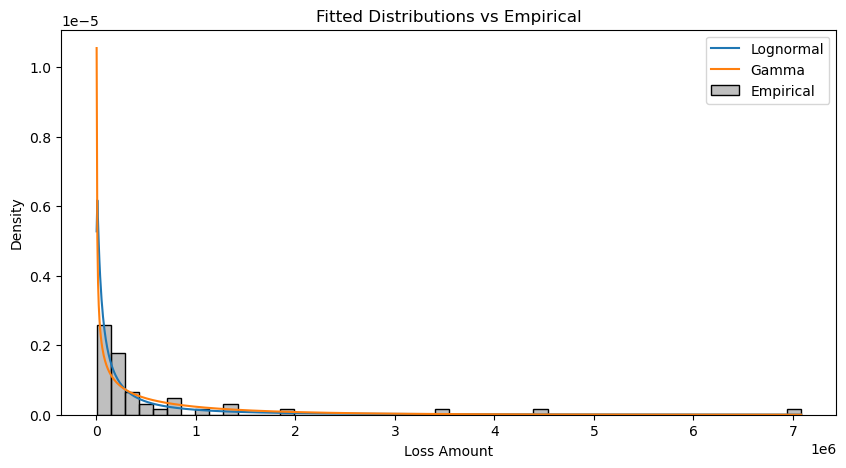

In [18]:
# Step 4: Compare PDFs to data
x = np.linspace(min(losses), max(losses), 1000)

plt.figure(figsize=(10, 5))
sns.histplot(losses, bins=50, stat='density', label='Empirical', color='gray', alpha=0.5)

plt.plot(x, stats.lognorm.pdf(x, shape_ln, loc=loc_ln, scale=scale_ln), label='Lognormal')
plt.plot(x, stats.gamma.pdf(x, alpha_g, loc=loc_g, scale=beta_g), label='Gamma')

plt.title("Fitted Distributions vs Empirical")
plt.xlabel("Loss Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

In [19]:
# Step 5: Goodness of Fit (Optional)
ks_stat_ln, ks_pvalue_ln = stats.kstest(losses, 'lognorm', args=(shape_ln, loc_ln, scale_ln))
ks_stat_g, ks_pvalue_g = stats.kstest(losses, 'gamma', args=(alpha_g, loc_g, beta_g))

print(f"Lognormal KS test: stat={ks_stat_ln:.4f}, p-value={ks_pvalue_ln:.4f}")
print(f"Gamma KS test: stat={ks_stat_g:.4f}, p-value={ks_pvalue_g:.4f}")

Lognormal KS test: stat=0.1415, p-value=0.3119
Gamma KS test: stat=0.1377, p-value=0.3424


In [20]:
empirical_stats = {
    "Minimum": np.min(losses),
    "Maximum": np.max(losses),
    "Mean": np.mean(losses),
    "Median": np.median(losses),
    "Mode": losses.mode().iloc[0] if not losses.mode().empty else np.nan,
    "Std Dev": np.std(losses, ddof=1),
    "Skewness": stats.skew(losses),
    "Kurtosis": stats.kurtosis(losses),  # excess kurtosis
}

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for q in quantiles:
    empirical_stats[f"{int(q*100)}%"] = np.quantile(losses, q)

In [21]:
# Fitted distribution stats
lognorm_fitted = stats.lognorm(s=shape_ln, loc=loc_ln, scale=scale_ln)
gamma_fitted = stats.gamma(a=alpha_g, loc=loc_g, scale=beta_g)

def dist_stats(dist):
    return {
        "Minimum": dist.ppf(0.001),
        "Maximum": dist.ppf(0.999),
        "Mean": dist.mean(),
        "Median": dist.median(),
        "Mode": dist.ppf((dist.cdf(dist.mean()) + dist.cdf(dist.median())) / 2),  # crude mode approx
        "Std Dev": dist.std(),
        "Skewness": dist.stats(moments='s'),
        "Kurtosis": dist.stats(moments='k'),
        **{f"{int(q*100)}%": dist.ppf(q) for q in quantiles}
    }

lognorm_stats = dist_stats(lognorm_fitted)
gamma_stats = dist_stats(gamma_fitted)

In [23]:
comparison_df = pd.DataFrame({
    "Empirical": empirical_stats,
    "Lognormal Fit": lognorm_stats,
    "Gamma Fit": gamma_stats
})
comparison_df

,Empirical,Lognormal Fit,Gamma Fit
Minimum,2.222299e+03,6.519957e+02,9.012920e-01
Maximum,7.082362e+06,5.206019e+07,7.283783e+06
Mean,6.675093e+05,9.765736e+05,6.675093e+05
Median,1.961010e+05,1.842363e+05,3.005757e+05
Mode,2.222299e+03,3.907663e+05,4.535203e+05
Std Dev,1.322573e+06,5.083529e+06,9.494382e+05
Skewness,3.458741e+00,1.566690e+02,2.844719e+00
Kurtosis,1.236923e+01,6.699388e+05,1.213864e+01
10%,1.020815e+04,1.773642e+04,1.007498e+04
25%,1.041503e+05,5.375008e+04,6.611322e+04
